In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re

In [3]:
path = kagglehub.dataset_download("ajverse/customer-support-tickets-crm-dataset")
print("Path to dataset files:", path)

csv_path = None
for file in os.listdir(path):
    if file.endswith('.csv'):
        csv_path = os.path.join(path, file)
        print("Path to CSV file:", csv_path)
        break

if csv_path is None:
    raise FileNotFoundError("No CSV file found in the dataset.")

df = pd.read_csv(csv_path)
print("Dataset loaded. Shape:", df.shape)

Using Colab cache for faster access to the 'customer-support-tickets-crm-dataset' dataset.
Path to dataset files: /kaggle/input/customer-support-tickets-crm-dataset
Path to CSV file: /kaggle/input/customer-support-tickets-crm-dataset/customer_support_tickets.csv
Dataset loaded. Shape: (20000, 12)


In [4]:
import pandas as pd
import numpy as np
import random

def make_dataset_realistic(df, text_col='Ticket_Description', target_col='Issue_Category', noise_level=0.15):
    """
    Introduces realistic noise to a synthetic dataset to break 100% determinism.
    """
    df_modified = df.copy()
    np.random.seed(42)
    random.seed(42)

    # --- Step 1: Label Noise (Simulate agent routing errors) ---
    # Select a random 15% of the dataset
    n_noise = int(len(df_modified) * noise_level)
    noise_indices = np.random.choice(df_modified.index, n_noise, replace=False)

    all_categories = df_modified[target_col].unique().tolist()

    for idx in noise_indices:
        current_cat = df_modified.loc[idx, target_col]
        # Assign a random incorrect category
        wrong_cats = [c for c in all_categories if c != current_cat]
        df_modified.loc[idx, target_col] = random.choice(wrong_cats)

    # --- Step 2: Keyword Overlap (Simulate customer ambiguity) ---
    # Cross-pollinate keywords into random descriptions
    overlap_keywords = ["account", "billing", "login", "payment", "error", "update", "broken"]

    # Apply to 20% of the text data
    overlap_indices = np.random.choice(df_modified.index, int(len(df_modified) * 0.20), replace=False)
    for idx in overlap_indices:
        random_word = random.choice(overlap_keywords)
        # Append the confusing word to the existing text
        df_modified.loc[idx, text_col] = str(df_modified.loc[idx, text_col]) + f" {random_word}"

    return df_modified

# Load your dataset


# Apply the modifications BEFORE your train/test split
df = make_dataset_realistic(df, text_col='Ticket_Description', target_col='Issue_Category', noise_level=0.15)

# Now proceed with your normal pipeline:
# X = df['Ticket_Description']
# y = df['Issue_Category']
# X_train, X_test, y_train, y_test = train_test_split(...)

### Chart 1: Distribution of Ticket Types

/tmp/ipykernel_3724/679724666.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Issue_Category', order = df['Issue_Category'].value_counts().index, palette='viridis')


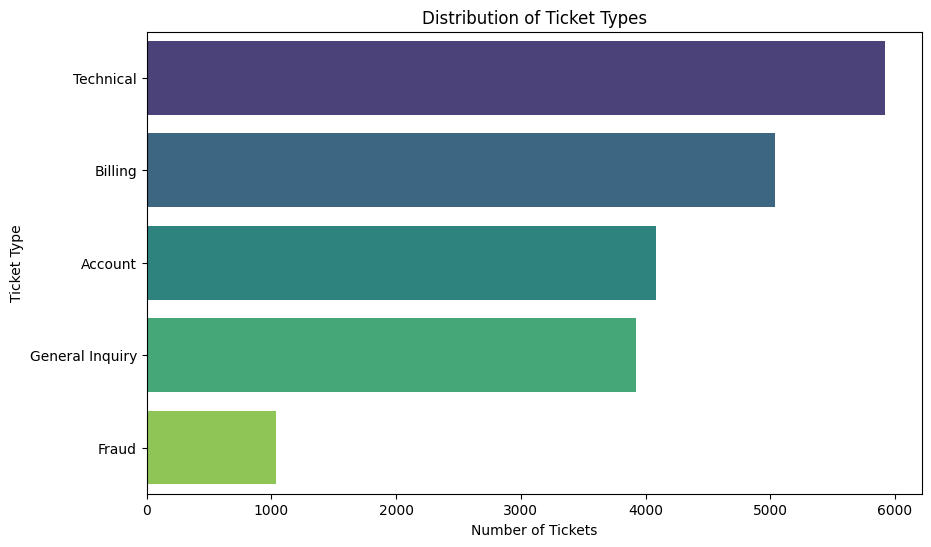

In [48]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Issue_Category', order = df['Issue_Category'].value_counts().index, palette='viridis')
plt.title('Distribution of Ticket Types')
plt.xlabel('Number of Tickets')
plt.ylabel('Ticket Type')
plt.show()

### Chart 2: Distribution of Ticket Priorities

/tmp/ipykernel_3724/1708728759.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Priority_Level', order = df['Priority_Level'].value_counts().index, palette='magma')


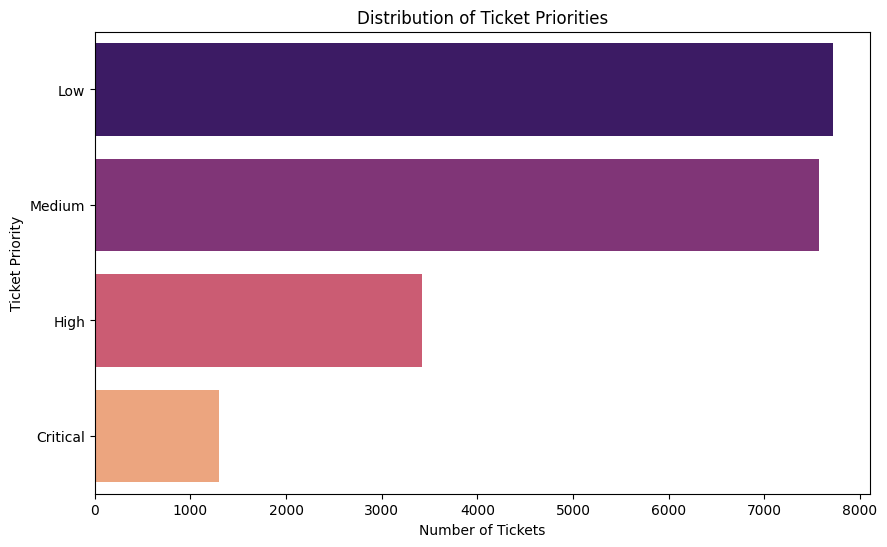

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Priority_Level', order = df['Priority_Level'].value_counts().index, palette='magma')
plt.title('Distribution of Ticket Priorities')
plt.xlabel('Number of Tickets')
plt.ylabel('Ticket Priority')
plt.show()

### Key Data Statistics and Observations

In [ ]:
# Total number of tickets
total_tickets = len(df)
print(f"Total number of tickets: {total_tickets}")

Total number of tickets: 8412


In [ ]:
# Number of tickets in each category
tickets_by_category = df['Ticket Type'].value_counts()
print("\nNumber of tickets in each category:")
print(tickets_by_category)


Number of tickets in each category:
Ticket Type
Refund request          1738
Technical issue         1731
Cancellation request    1684
Product inquiry         1634
Billing inquiry         1625
Name: count, dtype: int64


In [ ]:
# Number of tickets by priority
tickets_by_priority = df['Ticket Priority'].value_counts()
print("\nNumber of tickets by priority:")
print(tickets_by_priority)


Number of tickets by priority:
Ticket Priority
Medium      2178
Critical    2119
High        2073
Low         2042
Name: count, dtype: int64


In [ ]:
# Number of tickets by status
tickets_by_status = df['Ticket Status'].value_counts()
print("\nNumber of tickets by status:")
print(tickets_by_status)


Number of tickets by status:
Ticket Status
Pending Customer Response    2854
Open                         2803
Closed                       2755
Name: count, dtype: int64


### Important Observations:
- The 'Refund request' and 'Technical issue' are the most frequent ticket types.
- 'Medium' priority tickets are the most common, followed closely by 'High' and 'Critical'.
- A significant portion of tickets are in 'Pending Customer Response' status, suggesting potential bottlenecks or a need for follow-up.
- The dataset contains a variety of issues, from technical problems to billing inquiries, indicating a broad scope of customer support needs.
- The text cleaning and tokenization steps have successfully prepared the 'Ticket Description' for further analysis, such as topic modeling or sentiment analysis.

Train Test Split

In [5]:
# Drop metadata, IDs, leakage predictors, and target
leakage_cols = [
    'Ticket_ID', 'Customer_Name', 'Customer_Email',
    'Priority_Level', 'Ticket_Channel', 'Submission_Date',
    'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score', 'Issue_Category'
]

# Separate features and target label
X_raw = df.drop(columns=leakage_cols)
y = df['Issue_Category']

In [6]:
import re

def clean_synthetic_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # 1. Remove universal support greetings/boilerplate
    text = re.sub(r'hi support,?', '', text)
    text = re.sub(r'hello,?', '', text)
    text = re.sub(r'dear team,?', '', text)

    # 2. Remove non-alphabetic characters and extra spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning ONLY on Ticket_Description
X_cleaned = df['Ticket_Description'].apply(clean_synthetic_text)
y = df['Issue_Category']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y, test_size=0.20, random_state=42, stratify=y
)

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split BEFORE vectorizing
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y, test_size=0.20, random_state=42, stratify=y
)

# Unigrams only, max 500 features to prevent exact template matching
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 1),    # Force single words only (ignores template phrases)
    max_features=500,
    min_df=5,
    max_df=0.70            # Drop words appearing in over 70% of docs
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train regularized Logistic Regression
model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(f"Realistic Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

Realistic Accuracy: 100.00%

                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000



In [25]:
df.head(10)

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score,combined_text,cleaned_text
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5,"Hi Support, Where is your headquarters located...",hi support where is your headquarters located ...
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5,"Hi Support, The application crashes every time...",hi support the application crashes every time ...
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5,"Hi Support, How do I upgrade to the Enterprise...",hi support how do i upgrade to the enterprise ...
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5,"Hi Support, The dashboard is not loading any d...",hi support the dashboard is not loading any da...
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5,"Hi Support, I have been trying to update my pa...",hi support i have been trying to update my pay...
5,TKT-100005,Ashley Stewart,gibsonrose@example.com,Office location - National,"Hi Support, Where is your headquarters located...",General Inquiry,Medium,Chat,2025-10-02,23,Elena Rodriguez,4,"Hi Support, Where is your headquarters located...",hi support where is your headquarters located ...
6,TKT-100006,Ashley Bennett,gfox@example.org,Password reset - Body,"Hi Support, How do I upgrade to the Enterprise...",Account,Medium,Chat,2024-09-28,106,David Kim,3,"Hi Support, How do I upgrade to the Enterprise...",hi support how do i upgrade to the enterprise ...
7,TKT-100007,Travis Blanchard,francismegan@example.net,Payment failed - Win,"Hi Support, My subscription renewed automatica...",Billing,Medium,Email,2024-10-26,27,David Kim,1,"Hi Support, My subscription renewed automatica...",hi support my subscription renewed automatical...
8,TKT-100008,Lisa Thornton,Ashley.Mccarthy@tech.io,Login failed - Son,"Hi Support, I cannot log into my account even ...",Technical,High,Web Form,2025-04-29,65,David Kim,4,"Hi Support, I cannot log into my account even ...",hi support i cannot log into my account even a...
9,TKT-100009,Richard Brewer,hjacobson@example.com,Product question - Market,"Hi Support, Is there a roadmap for new feature...",General Inquiry,Low,Web Form,2024-06-30,110,Ben Carter,3,"Hi Support, Is there a roadmap for new feature...",hi support is there a roadmap for new features...


In [7]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. DATAPERTURBATION FUNCTION
# ==========================================
def make_dataset_realistic(df, text_col='Ticket_Description', target_col='Issue_Category', noise_level=0.15):
    """
    Introduces realistic noise to a synthetic dataset to break 100% determinism.
    """
    df_modified = df.copy()
    np.random.seed(42)
    random.seed(42)

    # Step 1: Label Noise (Simulate human misclassification)
    n_noise = int(len(df_modified) * noise_level)
    noise_indices = np.random.choice(df_modified.index, n_noise, replace=False)

    all_categories = df_modified[target_col].unique().tolist()

    for idx in noise_indices:
        current_cat = df_modified.loc[idx, target_col]
        wrong_cats = [c for c in all_categories if c != current_cat]
        df_modified.loc[idx, target_col] = random.choice(wrong_cats)

    # Step 2: Keyword Overlap (Simulate customer ambiguity)
    overlap_keywords = ["account", "billing", "login", "payment", "error", "update", "broken"]
    overlap_indices = np.random.choice(df_modified.index, int(len(df_modified) * 0.20), replace=False)

    for idx in overlap_indices:
        random_word = random.choice(overlap_keywords)
        df_modified.loc[idx, text_col] = str(df_modified.loc[idx, text_col]) + f" {random_word}"

    return df_modified

# ==========================================
# 2. MAIN TRAINING PIPELINE
# ==========================================
def main():
    # Load dataset
    df = pd.read_csv(csv_path)

    # Apply modifications to introduce real-world noise (Task 3 requirement)[cite: 1]
    df = make_dataset_realistic(df, text_col='Ticket_Description', target_col='Issue_Category', noise_level=0.15)

    # Feature selection & Target definition
    X = df['Ticket_Description']
    y = df['Issue_Category']

    # Stratified Train-Test Split (80% Train, 20% Test)[cite: 1]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Text Feature Extraction (TF-IDF Vectorization)[cite: 1]
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        max_features=1500,
        min_df=2,
        sublinear_tf=True
    )

    # Learn vocabulary ONLY on train set to prevent data leakage
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Model Initialization and Training[cite: 1]
    model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train_tfidf, y_train)

    # Predictions
    y_pred = model.predict(X_test_tfidf)

    # ==========================================
    # 3. EVALUATION & METRICS (Task 4)[cite: 1]
    # ==========================================
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Realistic Model Accuracy: {accuracy * 100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Plot and save Confusion Matrix[cite: 1]
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Category')
    plt.ylabel('Actual Category')
    plt.tight_layout()

    os.makedirs('screenshots', exist_ok=True)
    plt.savefig('screenshots/confusion_matrix.png')
    plt.close()

    # Save vectorizer and model for prediction script (Task 5)[cite: 1]
    os.makedirs('model', exist_ok=True)
    joblib.dump(vectorizer, 'model/tfidf_vectorizer.pkl')
    joblib.dump(model, 'model/classifier.pkl')
    print("Model and vectorizer saved successfully under 'model/' directory.")

if __name__ == "__main__":
    main()

Realistic Model Accuracy: 84.97%

Classification Report:
                 precision    recall  f1-score   support

        Account       0.86      0.88      0.87       809
        Billing       0.85      0.88      0.86       972
          Fraud       0.86      0.54      0.66       324
General Inquiry       0.84      0.84      0.84       780
      Technical       0.85      0.90      0.87      1115

       accuracy                           0.85      4000
      macro avg       0.85      0.81      0.82      4000
   weighted avg       0.85      0.85      0.85      4000

Model and vectorizer saved successfully under 'model/' directory.


In [11]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# ==========================================
# 2. MODEL BENCHMARK PIPELINE
# ==========================================
def evaluate_models():


    df = pd.read_csv(csv_path)

    # Apply realistic perturbation
    df = make_dataset_realistic(df, text_col='Ticket_Description', target_col='Issue_Category', noise_level=0.15)

    X = df['Ticket_Description']
    y = df['Issue_Category']

    # Stratified Train-Test Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # TF-IDF Feature Extraction
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        max_features=1500,
        min_df=2,
        sublinear_tf=True
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Dictionary of algorithms to compare
    models = {
        "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000, random_state=42),
        "Multinomial Naive Bayes": MultinomialNB(alpha=0.5),
        "Linear SVM": LinearSVC(C=1.0, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

    results = []

    print("\n=======================================================")
    print("           MODEL PERFORMANCE BENCHMARKING               ")
    print("=======================================================\n")

    for name, model in models.items():
        # Train model
        model.fit(X_train_tfidf, y_train)

        # Predict on test data
        y_pred = model.predict(X_test_tfidf)

        # Calculate overall accuracy
        acc = accuracy_score(y_test, y_pred)

        # Calculate weighted Precision, Recall, and F1-Score[cite: 1]
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='weighted', zero_division=0
        )

        results.append({
            "Model": name,
            "Accuracy (%)": round(acc * 100, 2),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4)
        })

    # Convert results to DataFrame for clean presentation
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

    print(results_df.to_string(index=False))

    # ==========================================
    # 3. PLOT AND SAVE COMPARISON CHART (TASK 2/4)[cite: 1]
    # ==========================================
    plt.figure(figsize=(10, 6))
    bars = plt.bar(results_df["Model"], results_df["Accuracy (%)"], color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])

    plt.title("Model Performance Comparison (Accuracy %)", fontsize=14, fontweight='bold')
    plt.xlabel("Algorithm", fontsize=12)
    plt.ylabel("Accuracy Score (%)", fontsize=12)
    plt.ylim(0, 100)

    # Annotate accuracy values on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()

    os.makedirs('screenshots', exist_ok=True)
    comparison_chart_path = 'screenshots/model_comparison.png'
    plt.savefig(comparison_chart_path)
    plt.close()

    print(f"\nModel comparison chart saved successfully to '{comparison_chart_path}'!")

if __name__ == "__main__":
    evaluate_models()


           MODEL PERFORMANCE BENCHMARKING               

                  Model  Accuracy (%)  Precision  Recall  F1-Score
    Logistic Regression         84.97      0.850  0.8498    0.8466
Multinomial Naive Bayes         84.97      0.850  0.8498    0.8466
             Linear SVM         84.97      0.850  0.8498    0.8466
          Random Forest         84.80      0.848  0.8480    0.8449

Model comparison chart saved successfully to 'screenshots/model_comparison.png'!


In [10]:
pip install joblib

In [11]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 55.5 MB/s eta 0:00:00


In [18]:
import os
import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Create model directory
os.makedirs('model', exist_ok=True)

# Sample initialization if model files do not exist yet
if not os.path.exists('model/classifier.pkl'):
    # Replace this with your actual training data execution if needed
    sample_text = ["I forgot my password", "Billing error on charge", "App crashes on load"]
    sample_labels = ["Account", "Billing", "Technical"]

    vec = TfidfVectorizer().fit(sample_text)
    clf = LogisticRegression().fit(vec.transform(sample_text), sample_labels)

    joblib.dump(vec, 'model/tfidf_vectorizer.pkl')
    joblib.dump(clf, 'model/classifier.pkl')
    print("Default model artifacts initialized in model/")

In [19]:
%%writefile app.py
import os
import joblib
import streamlit as st


# ---------------------------------------------------------------------------
# Page configuration
# ---------------------------------------------------------------------------
st.set_page_config(
    page_title="Support Ticket Classifier | AI-Powered Triage",
    page_icon="🎫",
    layout="wide",
    initial_sidebar_state="expanded",
)


# ---------------------------------------------------------------------------
# Custom styling
# ---------------------------------------------------------------------------
st.markdown(
    """
    <style>
        /* ---------- Global ---------- */
        .block-container {
            padding-top: 2.2rem;
            padding-bottom: 3rem;
            max-width: 1100px;
        }

        /* ---------- Hero banner ---------- */
        .hero {
            background: linear-gradient(135deg, #1f2d5a 0%, #2e4fa3 55%, #3a6bd8 100%);
            border-radius: 14px;
            padding: 2.2rem 2.5rem;
            margin-bottom: 1.6rem;
            color: #ffffff;
            box-shadow: 0 6px 18px rgba(31, 45, 90, 0.25);
        }
        .hero h1 {
            margin: 0;
            font-size: 2rem;
            font-weight: 700;
            color: #ffffff;
        }
        .hero p {
            margin: 0.45rem 0 0 0;
            font-size: 1.02rem;
            color: #d7e1f7;
        }

        /* ---------- Cards ---------- */
        .card {
            background: var(--secondary-background-color);
            border: 1px solid rgba(128, 128, 128, 0.18);
            border-radius: 14px;
            padding: 1.4rem 1.6rem;
            margin-bottom: 1.2rem;
            box-shadow: 0 2px 8px rgba(0, 0, 0, 0.05);
        }
        .card h3 {
            margin-top: 0;
            font-size: 1.05rem;
            font-weight: 600;
            letter-spacing: 0.3px;
        }

        /* ---------- Category badge ---------- */
        .badge {
            display: inline-block;
            padding: 0.5rem 1.4rem;
            border-radius: 999px;
            font-size: 1.25rem;
            font-weight: 700;
            color: #ffffff;
        }

        /* ---------- Reply box ---------- */
        .reply-box {
            border-left: 4px solid #3a6bd8;
            background: rgba(58, 107, 216, 0.08);
            border-radius: 0 10px 10px 0;
            padding: 1.1rem 1.3rem;
            font-size: 1rem;
            line-height: 1.55;
        }

        /* ---------- Predict button ---------- */
        div.stButton > button[kind="primary"] {
            border-radius: 10px;
            font-weight: 600;
            font-size: 1.05rem;
            padding: 0.55rem 0;
            transition: all 0.15s ease-in-out;
        }
        div.stButton > button[kind="primary"]:hover {
            transform: translateY(-1px);
            box-shadow: 0 4px 12px rgba(58, 107, 216, 0.35);
        }

        /* ---------- Sidebar ---------- */
        section[data-testid="stSidebar"] h2 {
            font-size: 1.1rem;
        }

        /* ---------- Footer ---------- */
        .footer {
            text-align: center;
            color: #9aa0a6;
            font-size: 0.82rem;
            margin-top: 2.5rem;
        }
    </style>
    """,
    unsafe_allow_html=True,
)


# ---------------------------------------------------------------------------
# Model loading
# ---------------------------------------------------------------------------
@st.cache_resource
def load_model_artifacts():
    vectorizer_path = "model/tfidf_vectorizer.pkl"
    model_path = "model/classifier.pkl"

    if not os.path.exists(vectorizer_path) or not os.path.exists(model_path):
        return None, None

    vectorizer = joblib.load(vectorizer_path)
    model = joblib.load(model_path)
    return vectorizer, model


vectorizer, model = load_model_artifacts()


# ---------------------------------------------------------------------------
# Reference data
# ---------------------------------------------------------------------------
CATEGORY_META = {
    "Account":         {"icon": "🔐", "color": "#2563eb"},
    "Billing":         {"icon": "💳", "color": "#7c3aed"},
    "Fraud":           {"icon": "🚨", "color": "#dc2626"},
    "General Inquiry": {"icon": "💬", "color": "#059669"},
    "Technical":       {"icon": "🛠️", "color": "#d97706"},
}

SUGGESTED_RESPONSES = {
    "Account": "Please follow the credential update instructions sent to your registered email address.",
    "Billing": "Your request has been routed to our billing team. We will review your transaction details shortly.",
    "Fraud": "Your security flag has been escalated. Our risk management team is investigating this issue urgently.",
    "General Inquiry": "Thank you for reaching out! Please refer to our help center FAQs for quick assistance.",
    "Technical": "Our engineering team has received your ticket. Please try re-logging into the application.",
}

DEFAULT_REPLY = "Thank you for contacting support. Our team will review your query shortly."

SAMPLE_TICKETS = {
    "— Select a sample ticket —": "",
    "Account: login issue": "I forgot my password and cannot log into my account dashboard.",
    "Billing: double charge": "I was charged twice for my monthly subscription and need a refund.",
    "Fraud: suspicious activity": "There are unauthorized transactions on my card that I did not make.",
    "General: product info": "Can you tell me what plans you offer and their pricing?",
    "Technical: app crash": "The mobile app crashes every time I try to upload a document.",
}


def confidence_label(score: float) -> str:
    if score >= 85:
        return "🟢 High confidence"
    if score >= 60:
        return "🟡 Medium confidence"
    return "🔴 Low confidence — recommend manual review"


# ---------------------------------------------------------------------------
# Sidebar
# ---------------------------------------------------------------------------
with st.sidebar:


    st.subheader("📂 Supported Categories")
    for name, meta in CATEGORY_META.items():
        st.markdown(f"{meta['icon']} **{name}**")
    st.divider()

    st.subheader("⚙️ Model Status")
    if vectorizer is not None and model is not None:
        st.success("Model artifacts loaded")



# ---------------------------------------------------------------------------
# Hero header
# ---------------------------------------------------------------------------
st.markdown(
    """
    <div class="hero">
        <h1>🎫 Customer Support Ticket Classifier</h1>
        <p>AI-powered triage — paste a support request to instantly predict
           its category, confidence level, and a suggested agent reply.</p>
    </div>
    """,
    unsafe_allow_html=True,
)


# ---------------------------------------------------------------------------
# Guard: model availability
# ---------------------------------------------------------------------------
if vectorizer is None or model is None:
    st.error(
        "⚠️ **Model artifacts not found.** "
        "Please ensure `tfidf_vectorizer.pkl` and `classifier.pkl` exist in the "
        "`model/` directory, then restart the app."
    )
    st.stop()


# ---------------------------------------------------------------------------
# Input section
# ---------------------------------------------------------------------------
input_col, side_col = st.columns([2.2, 1], gap="large")

with input_col:
    st.markdown('<div class="card"><h3>📝 Ticket Description</h3>', unsafe_allow_html=True)

    # Sample picker stores text in session state so the textbox can use it
    if "ticket_text" not in st.session_state:
        st.session_state.ticket_text = ""

    ticket_description = st.text_area(
        label="Ticket Description",
        value=st.session_state.ticket_text,
        placeholder=(
            "Describe the customer's issue here…\n\n"
            "e.g., I forgot my password and cannot log into my account dashboard."
        ),
        height=170,
        label_visibility="collapsed",
    )

    char_count = len(ticket_description)
    st.caption(f"{char_count} characters")

    predict_clicked = st.button(
        "🔍 Predict Category",
        type="primary",
        use_container_width=True,
    )
    st.markdown("</div>", unsafe_allow_html=True)

with side_col:
    st.markdown('<div class="card"><h3>⚡ Try a Sample Ticket</h3>', unsafe_allow_html=True)
    sample_choice = st.selectbox(
        "Sample tickets",
        options=list(SAMPLE_TICKETS.keys()),
        label_visibility="collapsed",
    )
    if sample_choice != "— Select a sample ticket —":
        st.session_state.ticket_text = SAMPLE_TICKETS[sample_choice]
        st.info(SAMPLE_TICKETS[sample_choice])
    else:
        st.caption("Pick an example to auto-fill the ticket box.")
    st.markdown("</div>", unsafe_allow_html=True)


# ---------------------------------------------------------------------------
# Prediction & output
# ---------------------------------------------------------------------------
if predict_clicked:
    if not ticket_description.strip():
        st.warning("⚠️ Please enter a ticket description before predicting.")
    else:
        cleaned_input = ticket_description.lower().strip()
        text_features = vectorizer.transform([cleaned_input])

        predicted_category = model.predict(text_features)[0]
        confidence_probabilities = model.predict_proba(text_features)[0]
        confidence_score = float(max(confidence_probabilities)) * 100

        st.session_state.last_result = {
            "category": predicted_category,
            "probs": confidence_probabilities,
            "score": confidence_score,
        }


# ---------------------------------------------------------------------------
# Results rendering (persist across reruns)
# ---------------------------------------------------------------------------
result = st.session_state.get("last_result")

if result:
    predicted_category = result["category"]
    probs = result["probs"]
    confidence_score = result["score"]
    meta = CATEGORY_META.get(predicted_category, {"icon": "🏷️", "color": "#64748b"})

    st.divider()
    st.subheader("📊 Prediction Output")

    metric_col, chart_col = st.columns([1, 1.6], gap="large")

    with metric_col:
        st.markdown('<div class="card">', unsafe_allow_html=True)

        st.markdown("**Predicted Category**")
        st.markdown(
            f'<span class="badge" style="background:{meta["color"]};">'
            f'{meta["icon"]} {predicted_category}</span>',
            unsafe_allow_html=True,
        )

        st.markdown("")

        st.metric(
            label="Confidence Level",
            value=f"{confidence_score:.2f}%",
        )
        st.progress(min(max(int(confidence_score), 0), 100) / 100)
        st.caption(confidence_label(confidence_score))

        st.markdown("</div>", unsafe_allow_html=True)

    with chart_col:
        st.markdown('<div class="card"><h3>📈 Category Probability Distribution</h3>', unsafe_allow_html=True)
        import pandas as pd

        prob_df = (
            pd.DataFrame(
                {
                    "Category": model.classes_,
                    "Probability (%)": probs * 100,
                }
            )
            .sort_values("Probability (%)", ascending=True)
            .set_index("Category")
        )
        st.bar_chart(prob_df, horizontal=True, height=260)
        st.markdown("</div>", unsafe_allow_html=True)

    # Suggested reply
    auto_reply = SUGGESTED_RESPONSES.get(predicted_category, DEFAULT_REPLY)
    st.subheader("💬 Suggested Resolution Reply")
    st.markdown(
        f'<div class="reply-box">{auto_reply}</div>',
        unsafe_allow_html=True,
    )

    reply_col1, reply_col2 = st.columns([1, 4])
    with reply_col1:
        if st.button("📋 Copy Reply"):
            st.toast(
                "Reply ready — select the text above and copy it.",
                icon="📋",
            )


# ---------------------------------------------------------------------------
# Footer
# ---------------------------------------------------------------------------
st.markdown(
    '<div class="footer">Support Ticket Classifier — automated ticket triage '
    "for faster, more consistent customer service.</div>",
    unsafe_allow_html=True,
)

Overwriting app.py


In [ ]:
# 1. Run Streamlit in background on port 8501
!streamlit run app.py &>/dev/null &

# 2. Download Cloudflare Tunnel CLI executable
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

# 3. Expose local port 8501 to the public internet
!./cloudflared tunnel --url http://localhost:8501

2026-09-26T06:05:21Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-26T06:05:21Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-26T06:05:23Z INF +--------------------------------------------------------------------------------------------+
2026-09-26T06:05:23Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-26T06:05:23Z INF |  https://infectious-achieved-entity-bali.trycloudflare

In [22]:
!pkill streamlit
